In [1]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import os
from yfinance import ticker
import time as time


In [2]:
def get_sp500_tickers():
    """Fetch the list of S&P 500 tickers from Wikipedia."""
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    table = soup.find('table', {'id': 'constituents'})
    tickers = []
    for row in table.findAll('tr')[1:]:
        ticker = row.findAll('td')[0].text.strip()
        tickers.append(ticker)
    return tickers

tickers = get_sp500_tickers()

start_time = time.time()
#Add multithreading program
stock_data = []
for x in tickers:
    try:
        ticker = yf.Ticker(str(x))
        ticker_hist = ticker.history(period = "5y")
       
        min_value = ticker_hist['Close'].min()
        max_value = ticker_hist['Close'].max()
        current_value = ticker_hist['Close'].iloc[-1]
        weight = max_value-min_value
        score = (max_value-current_value)/(current_value-min_value)
        
       
        stock_dict = {
            "ticker" : x,
            "score": score,
            "weight": weight,
            "weighted_score": score/weight
        }
        stock_data.append(stock_dict)
        
    except Exception as e:
        print("No data on " + x)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")

In [4]:
import concurrent.futures
def fetch_stock_data(ticker):
    try:
        ticker_obj = yf.Ticker(str(ticker))
        ticker_hist = ticker_obj.history(period="5y")
        
        if ticker_hist.empty:
            print(f"No data on {ticker}")
            return None
        
        min_value = ticker_hist['Close'].min()
        max_value = ticker_hist['Close'].max()
        current_value = ticker_hist['Close'].iloc[-1]
        weight = max_value - min_value
        score = (max_value - current_value) / (current_value - min_value)
        
        return {
            "ticker": ticker,
            "score": score,
            "weight": weight,
            "weighted_score": score / weight if weight != 0 else 0
        }
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return None

def fetch_all_stocks(tickers):
    stock_data = []
    with concurrent.futures.ThreadPoolExecutor() as executor:
        results = executor.map(fetch_stock_data, tickers)
    
    stock_data = [res for res in results if res is not None]
    return stock_data

stock_data = fetch_all_stocks(tickers)

$BF.B: possibly delisted; no price data found  (period=5y)


No data on BF.B


$BRK.B: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


No data on BRK.B
Elapsed time: 27.28314995765686 seconds


In [5]:
df = pd.DataFrame(stock_data).sort_values(by="score")
df = df[df["score"] != 0]

In [6]:
deals = df.tail(125)
deals

,ticker,score,weight,weighted_score
277,KHC,0.713410,22.947876,0.031088
317,MAA,0.713480,132.666023,0.005378
220,HAL,0.721199,37.877637,0.019040
257,IQV,0.740666,198.609985,0.003729
291,LMT,0.745105,367.097076,0.002030
...,...,...,...,...
438,TFX,31.780693,262.245544,0.121187
147,DG,45.559728,181.415344,0.251135
248,INTC,46.205781,43.193333,1.069743
361,PARA,50.676207,81.290910,0.623393


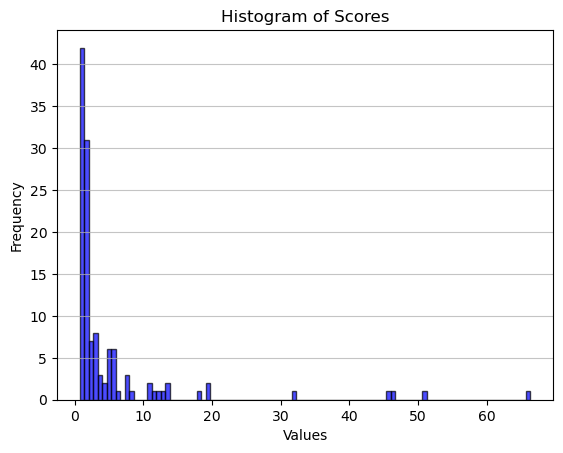

In [7]:
import matplotlib.pyplot as plt

# Plot histogram using Pandas
deals['score'].plot(kind='hist', bins=100, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Scores')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()

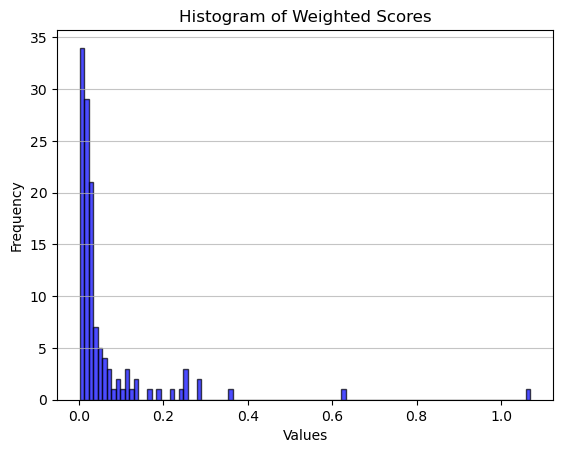

In [8]:
# Plot histogram using Pandas
deals['weighted_score'].plot(kind='hist', bins=100, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Weighted Scores')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()

In [9]:
high_scores = df[df["score"] >= 10]
high_scores

,ticker,score,weight,weighted_score
14,ARE,10.741297,111.215981,0.096581
479,WBA,10.841537,37.516588,0.288980
130,CCI,11.358141,99.505608,0.114146
406,SBAC,12.268481,189.460526,0.064755
58,BAX,12.723796,56.747900,0.224216
298,MKTX,13.268405,375.618103,0.035324
176,EL,13.507325,292.205128,0.046225
482,WBD,17.993269,70.559997,0.255007
318,MRNA,19.196665,466.240002,0.041173
304,MTCH,19.666639,146.224882,0.134496


In [10]:
score1y = []
for x in deals['ticker']:
    try:
        ticker = yf.Ticker(str(x))
        ticker_hist = ticker.history(period = "1y")
       
        min_value = ticker_hist['Close'].min()
        max_value = ticker_hist['Close'].max()
        current_value = ticker_hist['Close'].iloc[-1]
        if (current_value-min_value) == 0:
            score = 0
        else:
            score = (max_value-current_value)/(current_value-min_value)
        score1y.append(score)
        

    except Exception as e:
        print("Error at " +x)
deals['score1y'] = score1y

C:\Users\owenh\AppData\Local\Temp\ipykernel_4292\1733646730.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  deals['score1y'] = score1y


In [11]:
# Load the S&P 500 dataset
url = "https://datahub.io/core/s-and-p-500-companies/r/constituents.csv"  # Replace with your dataset URL or file path
df = pd.read_csv(url)

# Extract the ticker, sector, and industry columns
tickers = df['Symbol'].tolist()
sectors = df['GICS Sector'].tolist()
industries = df['GICS Sub-Industry'].tolist()

Tickers: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN']
Sectors: ['Industrials', 'Industrials', 'Health Care', 'Health Care', 'Information Technology']
Industries: ['Industrial Conglomerates', 'Building Products', 'Health Care Equipment', 'Biotechnology', 'IT Consulting & Other Services']


In [12]:
#Makes a df with sector and industry information
infoFrame = pd.DataFrame({
    'ticker': tickers, 
    'sector': sectors, 
    'industry': industries})

In [13]:
#Adds the industry and sector columns to the dataframe
merged_df = pd.merge(infoFrame, deals, on='ticker', how='inner')

In [14]:
#Gets dividend T/F for each stock on the narrowed ticker list (long)
with_divs = []
for x in merged_df['ticker']:
    divs = yf.Ticker(x).dividends
    
    if len(divs) > 0:
        with_divs.append(x)

In [15]:
#Adds a column that indicates if a stock has a dividend
merged_df["divs"] = merged_df['ticker'].apply(lambda x: x in with_divs)


In [16]:
#Groups stocks with a dividend by sector
grouped_sectors = {sector: group for sector, group in merged_df[merged_df['divs'] == True].groupby('sector')}

#Groups stocks with no dividend by sector
grouped_nDivs = {sector: group for sector, group in merged_df[merged_df['divs'] == False].groupby('sector')}



In [17]:
#Prints data on stocks with dividends
for sector, group in grouped_sectors.items():
    print(f"Sector: {sector}")
    print(group.drop(columns = ['sector','weight', 'weighted_score', 'divs']).sort_values(by="score" ,ascending=False))
    print()

Sector: Communication Services
    ticker                        industry      score    score1y
97    PARA          Movies & Entertainment  50.676207   2.088950
82    MTCH    Interactive Media & Services  19.666639   0.493956
119    DIS          Movies & Entertainment   2.506118   0.319501
32   CMCSA               Cable & Satellite   1.784848   6.264969
48      EA  Interactive Home Entertainment   1.577170  97.550339

Sector: Consumer Discretionary
    ticker                             industry     score    score1y
94     NKE  Apparel, Accessories & Luxury Goods  5.400380   4.570843
11    APTV         Automotive Parts & Equipment  3.934130   2.306505
77     LVS                     Casinos & Gaming  1.704674   1.858759
63     HAS                     Leisure Products  1.514642   1.187211
56       F             Automobile Manufacturers  1.499585   5.011944
121   WYNN                     Casinos & Gaming  1.271693   2.022180
101   POOL                         Distributors  1.151327   1.38

In [18]:
#Prints data on stocks without dividends
for sector, group in grouped_nDivs.items():
    print(f"Sector: {sector}")
    print(group.drop(columns = ['sector','weight', 'weighted_score', 'divs']).sort_values(by="score" ,ascending=False))
    print()

Sector: Communication Services
    ticker           industry      score   score1y
120    WBD       Broadcasting  17.993269  0.555855
30    CHTR  Cable & Satellite   4.459803  0.469585

Sector: Consumer Discretionary
   ticker                        industry     score   score1y
22    CZR                Casinos & Gaming  2.954609  2.460786
3    ABNB  Hotels, Resorts & Cruise Lines  1.692385  1.839423
25    KMX               Automotive Retail  1.661949  0.074442
90    MHK                Home Furnishings  1.532268  1.592018
95   NCLH  Hotels, Resorts & Cruise Lines  1.334866  0.000000

Sector: Consumer Staples
   ticker                             industry     score   score1y
43   DLTR  Consumer Staples Merchandise Retail  7.499248  5.697586

Sector: Financials
   ticker                                   industry     score   score1y
99   PYPL  Transaction & Payment Processing Services  5.732915  0.094143

Sector: Health Care
    ticker                        industry      score    score1y


In [19]:
#merged_df.to_csv('stocks.csv')

In [48]:
merged_df

,ticker,sector,industry,score,weight,weighted_score,score1y,divs
0,ADBE,Information Technology,Application Software,1.488077,413.169983,0.003602,5.456204,True
1,AMD,Information Technology,Semiconductors,1.196051,172.670006,0.006927,28.665223,False
2,AES,Utilities,Independent Power Producers & Energy Traders,5.481540,19.004984,0.288426,72.729782,True
3,ABNB,Consumer Discretionary,"Hotels, Resorts & Cruise Lines",1.692385,134.349998,0.012597,1.839423,False
4,AKAM,Information Technology,Internet Services & Infrastructure,0.948883,57.570007,0.016482,1.956036,False
...,...,...,...,...,...,...,...,...
120,WBD,Communication Services,Broadcasting,17.993269,70.559997,0.255007,0.555855,False
121,WYNN,Consumer Discretionary,Casinos & Gaming,1.271693,95.180222,0.013361,2.022180,True
122,ZBRA,Information Technology,Electronic Equipment & Instruments,0.903689,453.039993,0.001995,0.135176,False
123,ZBH,Health Care,Health Care Equipment,1.605369,93.072327,0.017249,2.197667,True


In [50]:
#sp500 investment = ineffecient allocation of capital